In [2]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
from matplotlib import cm
#from matplotlib import norm
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')
import os

datadir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MultipleMeasuresTlife/Data/'
datadir2  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_Relaxation/Data/'
plotsdir  = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MultipleMeasuresTlife/Plots/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current recursion limit: 6000


In [3]:
def phiform(phi0,phi_inf,tau,t):
    if tau==0:
        phi = phi_inf
    else:
        phi = (phi0)*np.exp(-t/tau)+phi_inf
    return phi

def intersection(y,y0):
    diff = []
    for i in range(len(y)):
        #print(i)
        diff.append(float((y[i]-y0)*(y[i]-y0)))
    diff2 = sorted(diff)
    x = diff.index(diff2[0])
    return x,diff[x]

In [4]:
cmap0 = plt.cm.get_cmap('YlOrBr') #YlOrBr
clrs1= ['#edf8b1','#7fcdbb','#2c7fb8']
clrs2=['#f7fcb9','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['#e7e1ef','#c994c7','#dd1c77']

clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','dimgrey']
#clrs_5 = ['#c7e9b4','#7fcdbb','#41b6c4','#2c7fb8','#253494']
clrs1= ['grey','#7fcdbb','#2c7fb8']
clrs2=['grey','#addd8e','#31a354']
#clrs2= ['#ece2f0','#a6bddb','#1c9099']
clrs3 = ['grey','#c994c7','#dd1c77']
clrs_div = ['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f']
clrrrs=[clrs1,clrs3,clrs2]

#'YlOrBr'
ClrsRici = ["#96a2c1ff","#999ebeff","#a697baff","#b795afff","#c996a8ff","#d398a5ff"]
ClrsRici = ["#7883acff","#3e387bff","#73457aff","#a66181ff","#b25268ff","#d49995ff"]
ClrsRiciChosen = ClrsRici #["#7883acff","#73457aff","#b25268ff","#d49995ff"]
ClrsOrange = ["#fed98e","#fe9929","#d95f0e","#993404"]

/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures/Fig_MultipleMeasuresTlife/Data/Turnover_Different_times.dat


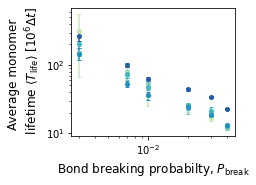

In [5]:
fig2,ax2 = plt.subplots(1,figsize = (3.5,2.6))
filename = 'Turnover_Different_times.dat'
print(datadir+filename)
LifeTimeData = pandas.read_csv(datadir+filename, header = 'infer',sep=' ')
f=3
MP = "0.12 0.1 0.06 0.03 0.02 0.01".split() # ORIGINAL RANGE  0.12 0.1 0.06 0.03 0.02 0.01
BP = "0.04 0.03 0.02 0.01 0.007 0.003".split() # ORIGINAL RANGE 0.04 0.03 0.02 0.01 0.007 0.003
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
for i in range(len(LifeTimeData.BP)):
    if LifeTimeData.TimeWindow[i]==1:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[0],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.TimeWindow[i]==2:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[1],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.TimeWindow[i]==3:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[2],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.TimeWindow[i]==4:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[3],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeData.TimeWindow[i]==5:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[4],capsize = 2,marker = 'o',markersize = 4)
#ax2.errorbar(BPsV[f],np.mean(IndividualT_MonRelase),yerr = np.std(IndividualT_MonRelase),capsize = 2,color = clrs_5[f],marker = 'o',markersize = 4) ##Would this by x2??
#ax2.plot(BPsV[f],np.divide(np.mean(IndividualT_MonRelase),10**6),color = clrs_5[f],marker = 'o',markersize = 10) ##Would this by x2??
#print(MP[f],np.mean(IndividualT_MonRelase),np.std(IndividualT_MonRelase))
#ax[2].set_ylabel("Free monomer lifetime",fontsize = 12)
ax2.set_ylabel("Average monomer \n lifetime"+r" $ \langle T_{\mathrm{life}}\rangle$ [$10^6\Delta t$]",fontsize = 12)
ax2.set_xlabel("Bond breaking probabilty, $P_{\mathrm{break}}$",fontsize = 12)
#ax2.set_yscale('log')
#ax2.set_yticks([0,100,200,300],['0','100','200','300'])
#ax2.set_ylim([0,350])
#print(AvTmonlife)
fig2.tight_layout()

ax2.set_yscale('log')
ax2.set_xscale('log')
#ax.set_ylim([70,100])
plotname = "EquilibriumMaster.pdf"
#fig.savefig(plotsdir+plotname)

plotname2 = "MonomerExchangeMaster.pdf"
#fig2.savefig(plotsdir+plotname2)
##plotname = "Equilibration_quants.pdf"


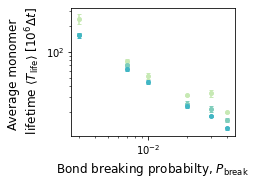

In [6]:
fig2,ax2 = plt.subplots(1,figsize = (3.5,2.6))
filename = 'Turnover_Different_stretches.dat'
LifeTimeDataStretch = pandas.read_csv(datadir+filename, header = 'infer',sep=' ')
f=3
MP = "0.12 0.1 0.06 0.03 0.02 0.01".split() # ORIGINAL RANGE  0.12 0.1 0.06 0.03 0.02 0.01
BP = "0.04 0.03 0.02 0.01 0.007 0.003".split() # ORIGINAL RANGE 0.04 0.03 0.02 0.01 0.007 0.003
BPsV = [0.04,0.03,0.02,0.01,0.007,0.003]
for i in range(len(LifeTimeDataStretch.BP)):
    if LifeTimeDataStretch.xstretch[i]==10:
        ax2.errorbar(LifeTimeDataStretch.BP[i],LifeTimeDataStretch.Turnover[i],yerr=LifeTimeDataStretch.Error[i],color = clrs_5[0],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeDataStretch.xstretch[i]==51:
        ax2.errorbar(LifeTimeDataStretch.BP[i],LifeTimeDataStretch.Turnover[i],yerr=LifeTimeDataStretch.Error[i],color = clrs_5[1],capsize = 2,marker = 'o',markersize = 4)
    if LifeTimeDataStretch.xstretch[i]==76:
        ax2.errorbar(LifeTimeDataStretch.BP[i],LifeTimeDataStretch.Turnover[i],yerr=LifeTimeDataStretch.Error[i],color = clrs_5[2],capsize = 2,marker = 'o',markersize = 4)

ax2.set_ylabel("Average monomer \n lifetime"+r" $ \langle T_{\mathrm{life}}\rangle$ [$10^6\Delta t$]",fontsize = 12)
ax2.set_xlabel("Bond breaking probabilty, $P_{\mathrm{break}}$",fontsize = 12)
fig2.tight_layout()
ax2.set_yscale('log')
ax2.set_xscale('log')

plotname = "EquilibriumMaster.pdf"

plotname2 = "MonomerExchangeMaster.pdf"
#fig2.savefig(plotsdir+plotname2)
##plotname = "Equilibration_quants.pdf"

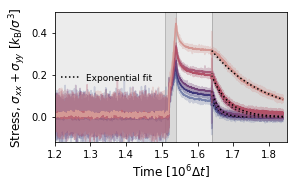

In [7]:
fig,ax = plt.subplots(1,figsize = (4.3,2.7))


xstretches = "51 76".split()
MPs = "0.1 0.03 0.01".split()
BPs = "0.03 0.01 0.003".split()
seeds1 = "1 2 3".split()
seeds2  = "1 3".split()


lenT0 = 75922
lenT1 = 3272
MPs = "0.12 0.1 0.06 0.03 0.02 0.01".split()
BPs = "0.04 0.03 0.02 0.01 0.007 0.003".split()
seeds1 = "1 2 3".split()
seeds2  = "1 3".split()
N=50

timeFactor = 10**6
t_Eq = (1509600*0.5)/timeFactor
t_MT = (1509600*0.5)/timeFactor +t_Eq
#endOfEq = 1509600
t_strain = ((20000+10000)/timeFactor)+t_MT
t_InitRel = 10000*10/timeFactor+t_strain
t_addmons = 1000/timeFactor +t_InitRel
t_FulLRel = 1000000/timeFactor+t_InitRel

times = [0,t_Eq,t_MT,t_strain,t_InitRel,t_FulLRel]
#strains=[0,0,0,100,100,100]
UP,LW=-0.15,0.65
#ax.plot(times,strains,linestyle = '-',color = 'black')
ax.fill_between([0,t_Eq],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
ax.fill_between([t_MT,t_strain],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
ax.fill_between([t_Eq,t_MT],[LW,LW],[UP,UP],alpha = 0.15,color = 'grey')
ax.fill_between([t_strain,t_InitRel],[LW,LW],[UP,UP],alpha = 0.15,color = 'grey')
ax.fill_between([t_InitRel,t_FulLRel],[LW,LW],[UP,UP],alpha = 0.15,color = 'black')
xstretches = "51 76".split()
x=1
#ax.set_ylabel("% applied x-y strain",fontsize =12)
ax.set_xlabel('Time [$10^{6}\Delta t$]',fontsize = 12)
#ax.set_xlim([-0.1,t_FulLRel+0.1])
#TmonAv = np.divide([64,100,330],10)
#22.8555011732714, 33.89276760171024, 44.545528358176234, 62.49702830973359, 100.25979092931783, 264.8313782857122
#TmonAv = [2,3,4,6,10,26]
#TmonAv = [3,6,26]
#Tmonstd = np.divide([3.571501191030219,5.480583457304206,13.19089058082929],10)
mrks = [":","-","--"]
alphs = [0.5,0.5,0.5]
Avtaus = []
Stdtaus = []

x=1
Vol1 = 51*51*12
Vol2 = (51+int(xstretches[x]))*(51+int(xstretches[x]))*12-Vol1
for p in range(len(MPs)):
    filename = 'stressdata_BP'+BP[p]+'.dat'
    
    StressData = pandas.read_csv(datadir2+filename, header = 'infer',sep=' ')
    Time_ = StressData.Time
    stressTotAv_ = StressData.stressAv
    stressTotAv,Time = stressTotAv_.values,Time_.values
    rollingAvRelax = np.convolve(stressTotAv[lenT0+lenT1:], np.ones(N)/N, mode='valid')
    timePostStretch = np.add(Time[lenT0+lenT1:],-Time[lenT0+lenT1])[int(N/2):-int(N/2-1)]
    stressPostStretch = rollingAvRelax
    
    phi_inf = 0
    phi0 = stressPostStretch[10]
    phiTau = phi0/np.exp(1)
    tau = timePostStretch[intersection(stressPostStretch,phiTau)[0]]
    phiTheory = []
    for tt in range(len(timePostStretch)):
        t = timePostStretch[tt]
        phiTheory.append(phiform(phi0,phi_inf,tau,t))
    
    ax.plot(np.divide(Time,timeFactor),stressTotAv,color = ClrsRiciChosen[p],alpha =0.3)
    #print(len(stressTotAv))
    #ax.plot(np.divide(Time[lenT0+lenT1:],timeFactor),stressTotAv[lenT0+lenT1:],color = 'black',alpha =0.3)
    N=50
    rollingAv = np.convolve(stressTotAv, np.ones(N)/N, mode='valid')
        #rollingAvY = np.convolve(stressY, np.ones(N)/N, mode='valid')
    timeAv = Time[int(N/2):-int(N/2-1)]
            
    ax.plot(np.divide(timeAv,timeFactor),rollingAv,color = ClrsRiciChosen[p],linestyle = '-')
    if p==0:
        ax.plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black',label = 'Exponential fit')
    else:
        ax.plot(np.divide(np.add(timePostStretch,Time[lenT0+lenT1]),timeFactor),phiTheory,linestyle = ':',color = 'black')


ax.set_ylabel(r'Stress, $\sigma_{xx}+\sigma_{yy}~[k_{\mathrm{B}}/\sigma^{3}]$',fontsize = 12)
ax.set_xlim([1.2,1.85])
ax.set_ylim([-0.12,0.5])
ax.legend(frameon=False,loc = [0.01,0.43],fontsize = 9)
fig.tight_layout()
plotname = "Stress_relaxation.pdf"
#fig.savefig(plotsdir + plotname)

In [9]:
#OtherData

Avtaus =[14234.0, 17030.666666666668, 21329.333333333332, 38244.666666666664, 48664.666666666664, 150533.33333333334] 
Stdtaus= [2172.0, 2103.1102892832055, 1442.1413091495422, 4186.233098569113, 5931.628519124313, 10291.6670931174]
#TmonAv = [3,6,26]
#Tmonstd = np.divide([3.571501191030219,5.480583457304206,13.19089058082929],10)

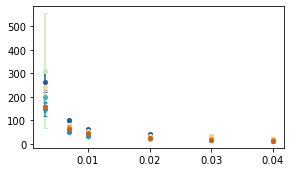

In [10]:
fig2,ax2 = plt.subplots(1,figsize = (4.5,2.6))

TURNOVER0 = []
TURNOVER0ERROR = []
TURNOVER1 = []
TURNOVER1ERROR = []
TURNOVER2 = []
TURNOVER2ERROR = []
TURNOVER3 = []
TURNOVER3ERROR = []
TURNOVER4 = []
TURNOVER4ERROR = []
for i in range(len(LifeTimeData.BP)):
    if LifeTimeData.TimeWindow[i]==1:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[0],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER0.append(LifeTimeData.Turnover[i])
        TURNOVER0ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==2:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[1],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER1.append(LifeTimeData.Turnover[i])
        TURNOVER1ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==3:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[2],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER2.append(LifeTimeData.Turnover[i])
        TURNOVER2ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==4:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[3],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER3.append(LifeTimeData.Turnover[i])
        TURNOVER3ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==5:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[4],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER4.append(LifeTimeData.Turnover[i])
        TURNOVER4ERROR.append(LifeTimeData.Error[i])

        
        
TURNOVERS0 = []
TURNOVERS0ERROR = []
TURNOVERS1 = []
TURNOVERS1ERROR = []
TURNOVERS2 = []
TURNOVERS2ERROR = []
for i in range(len(LifeTimeDataStretch.BP)):
    if LifeTimeDataStretch.xstretch[i]==10:
        ax2.errorbar(LifeTimeDataStretch.BP[i],LifeTimeDataStretch.Turnover[i],yerr=LifeTimeDataStretch.Error[i],color = ClrsOrange[0],capsize = 2,marker = 'o',markersize = 4)
        TURNOVERS0.append(LifeTimeDataStretch.Turnover[i])
        TURNOVERS0ERROR.append(LifeTimeDataStretch.Error[i])
    
    if LifeTimeDataStretch.xstretch[i]==51:
        ax2.errorbar(LifeTimeDataStretch.BP[i],LifeTimeDataStretch.Turnover[i],yerr=LifeTimeDataStretch.Error[i],color = ClrsOrange[1],capsize = 2,marker = 'o',markersize = 4)
        TURNOVERS1.append(LifeTimeDataStretch.Turnover[i])
        TURNOVERS1ERROR.append(LifeTimeDataStretch.Error[i])
    
    if LifeTimeDataStretch.xstretch[i]==76:
        ax2.errorbar(LifeTimeDataStretch.BP[i],LifeTimeDataStretch.Turnover[i],yerr=LifeTimeDataStretch.Error[i],color = ClrsOrange[2],capsize = 2,marker = 'o',markersize = 4)
        TURNOVERS2.append(LifeTimeDataStretch.Turnover[i])
        TURNOVERS2ERROR.append(LifeTimeDataStretch.Error[i])

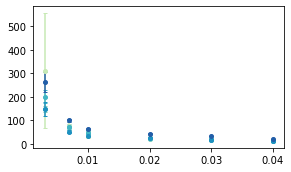

In [11]:
fig2,ax2 = plt.subplots(1,figsize = (4.5,2.6))

TURNOVER0 = []
TURNOVER0ERROR = []
TURNOVER1 = []
TURNOVER1ERROR = []
TURNOVER2 = []
TURNOVER2ERROR = []
TURNOVER3 = []
TURNOVER3ERROR = []
TURNOVER4 = []
TURNOVER4ERROR = []
for i in range(len(LifeTimeData.BP)):
    if LifeTimeData.TimeWindow[i]==1:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[0],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER0.append(LifeTimeData.Turnover[i])
        TURNOVER0ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==2:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[1],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER1.append(LifeTimeData.Turnover[i])
        TURNOVER1ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==3:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[2],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER2.append(LifeTimeData.Turnover[i])
        TURNOVER2ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==4:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[3],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER3.append(LifeTimeData.Turnover[i])
        TURNOVER3ERROR.append(LifeTimeData.Error[i])
    if LifeTimeData.TimeWindow[i]==5:
        ax2.errorbar(LifeTimeData.BP[i],LifeTimeData.Turnover[i],yerr=LifeTimeData.Error[i],color = clrs_5[4],capsize = 2,marker = 'o',markersize = 4)
        TURNOVER4.append(LifeTimeData.Turnover[i])
        TURNOVER4ERROR.append(LifeTimeData.Error[i])



In [12]:
print(TURNOVER4)
print(TURNOVER4ERROR)

[22.855501173271403, 33.89276760171025, 43.722336665819874, 62.49702830973359, 100.25979092931784, 264.83137828571216]
[0.3162006683245069, 1.4880313599705297, 1.8451907290684508, 5.032779997140776, 7.877407297906046, 43.0266762065278]


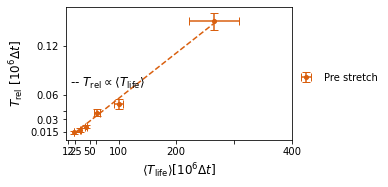

In [28]:
fig3,ax3 = plt.subplots(1,figsize = (5.5,2.7))

#y=mc+c
#0.15*20000 [0.01,0.15]
x1,y1 = np.array(TURNOVER4),np.array(Avtaus)
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
x2,y2 = np.array(TURNOVER2),np.array(Avtaus)
m2,b2 = np.polyfit(x2,y2,1)
x22 = x2.reshape(-1,1)
a2,_,_,_ = np.linalg.lstsq(x22, y2)
x3,y3 = np.array(TURNOVER3),np.array(Avtaus)
m3,b3 = np.polyfit(x3,y3,1)
x33 = x3.reshape(-1,1)
a3,_,_,_ = np.linalg.lstsq(x33, y3)
x4,y4 = np.array(TURNOVERS0),np.array(Avtaus)
m4,b4 = np.polyfit(x4,y4,1)
x44 = x4.reshape(-1,1)
a4,_,_,_ = np.linalg.lstsq(x44, y4)
ax3.errorbar(TURNOVER4,np.divide(Avtaus,10**6),xerr =TURNOVER4ERROR,yerr = np.divide(Stdtaus,10**6),color = ClrsOrange[2],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Pre stretch")
# ax3.errorbar(TURNOVER2,np.divide(Avtaus,10**6),xerr = TURNOVER2ERROR,yerr = np.divide(Stdtaus,10**6),color = clrs1[1],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Post stretch")
# ax3.errorbar(TURNOVER3,np.divide(Avtaus,10**6),xerr = TURNOVER3ERROR,yerr = np.divide(Stdtaus,10**6),color = clrs1[0],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Post relaxation")
# ax3.errorbar(TURNOVERS0,np.divide(Avtaus,10**6),xerr = TURNOVERS0ERROR,yerr = np.divide(Stdtaus,10**6),color = clrs1[2],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Post relaxation-\nSmall stretch")
# #ax3.errorbar(TURNOVER0,np.divide(Avtaus,10**6),xerr = TURNOVER0ERROR,yerr = np.divide(Stdtaus,10**6),color = clrs1[2],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Relax early")
# #ax3.errorbar(TURNOVER1,np.divide(Avtaus,10**6),xerr = TURNOVER1ERROR,yerr = np.divide(Stdtaus,10**6),color = ClrsOrange[1],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Relax during")
# #ax3.errorbar(TURNOVER2,np.divide(Avtaus,10**6),xerr = TURNOVER2ERROR,yerr = np.divide(Stdtaus,10**6),color = ClrsOrange[0],linestyle = '',marker = 'o',markersize = 4,capsize = 4,label ="Relax during")
# #ax3.plot(x1,np.divide(m1*x1+b1,10**6),linestyle = '-',color = ClrsOrange[2])
ax3.plot(x11,np.divide(a1*x11,10**6),linestyle = '--',color = ClrsOrange[2])
# #ax3.plot(x2,np.divide(m2*x2+b2,10**6),linestyle = '-',color = clrs1[1])
# ax3.plot(x22,np.divide(a2*x22,10**6),linestyle = '--',color = clrs1[1])
# #ax3.plot(x3,np.divide(m3*x3+b3,10**6),linestyle = '-',color = clrs1[0])
# ax3.plot(x33,np.divide(a3*x33,10**6),linestyle = '--',color = clrs1[0])
# #ax3.plot(x4,np.divide(m4*x4+b4,10**6),linestyle = '-',color = clrs1[2])
# ax3.plot(x44,np.divide(a4*x44,10**6),linestyle = '--',color = clrs1[2])
# print(m1,b1,a1)
# print(m2,b2,a2)
# print(m3,b3,a3)
# print(m4,b4,a4)
# # ax3.plot([17,300],[0.0005*20,0.0005*300],linestyle = '--',color = ClrsOrange[2]) #ClrsOrange[3])
# # ax3.plot([10,300*(10/17)],[0.0005*20,0.0005*300],linestyle = '--',color = clrs1[0]) #ClrsOrange[3])
# # ax3.plot([12,300*(12/17)],[0.0005*20,0.0005*300],linestyle = '--',color = clrs1[1]) #ClrsOrange[3])
# # ax3.plot([15,300*(15/17)],[0.0005*20,0.0005*300],linestyle = '--',color = clrs1[2]) #ClrsOrange[3])
# #ax3.plot([14.5,300*(14.5/15)],[0.0005*20,0.0005*300],linestyle = '--',color = ClrsOrange[1]) #ClrsOrange[3])
ax3.set_xlabel(r'$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
ax3.set_ylabel(r"$T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)
ax3.legend(frameon=False,loc = [1.,0.4])
text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'-- $T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
ax3.text(15,0.07,text,color = 'black',fontsize = 12)
#---- log-log axis---#
#ax3.set_yscale('log')
#ax3.set_xscale('log')
#ax3.set_xticks([25,50,60,100,200,300,400],['25','50','','100','200','','400'])
ax3.set_xticks([12,25,50,60,100,200,300,400],['12','25','50','','100','200','','400'])
ax3.set_yticks([0.015,0.03,0.04,0.06,0.12],['0.015','0.03','','0.06','0.12'])
#ax3.set_xlim([10,600])
fig3.tight_layout()
#---- normal axis ----#
plotname = 'MasterCurves_Times_linlin.pdf'
#plotname = 'Different_MasterCurves_Times.png'
fig3.savefig(plotsdir+plotname)